# Joint LDA: Stigma-Positive Discourse, Insider vs. Outsider

**Purpose.** Train a single LDA on the *combined* stigma-positive corpus
(drug subreddits + non-drug subreddits), then compare how the two cohorts
mix those shared topics. Because both cohorts are projected into the
same topic space, every cross-cohort difference reported here is a
difference in **how** insiders vs. outsiders talk about the same latent
themes, not an artefact of two independently trained models.

**Cohorts**

- `drug` — comments scraped from drug-related subreddits (likely
  substance users, "insider" voice).
- `non_drug` — comments scraped from non-drug subreddits (likely
  non-users discussing substances, "outsider" voice).

In [1]:
import os
import re
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from gensim.corpora.dictionary import Dictionary
from gensim.models import Phrases
from gensim.models.phrases import Phraser
from gensim.models.ldamodel import LdaModel
from gensim.models.coherencemodel import CoherenceModel

from scipy.stats import ttest_ind, norm
from scipy.spatial.distance import jensenshannon
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=DeprecationWarning)
sns.set_theme(style="whitegrid", context="talk")

for pkg in ("stopwords", "wordnet", "omw-1.4"):
    try:
        nltk.data.find(f"corpora/{pkg}")
    except LookupError:
        nltk.download(pkg, quiet=True)

# ---------------- Config ----------------
CSV_PATHS = {
    "drug":     "../reddit/drug_subreddit_pred_merge.csv",
    "non_drug": "../reddit/non_drug_subreddit_pred_merge.csv",
}
TEXT_COL = "dla_text"
LABEL_COL = "final_label"
STIGMA_VALUE = 1

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

PASSES = 10
ITERATIONS = 200
CHUNKSIZE = 2000

# Vocabulary / phrase hyperparameters
NO_BELOW = 20
NO_ABOVE = 0.5
MIN_TOKEN_LEN = 3
BIGRAM_MIN_COUNT = 20
BIGRAM_THRESHOLD = 10.0
LEMMATIZE = True

# Coherence sweep
COHERENCE_K_RANGE = list(range(4, 21, 2))   # 4, 6, ..., 20
COHERENCE_PASSES = 4
COHERENCE_ITERATIONS = 100

# Bootstrap / stats
N_BOOTSTRAP = 500
ALPHA = 0.05

# Output directory
OUT_DIR = Path("../reddit/topicmodel_joint_stigma")
OUT_DIR.mkdir(parents=True, exist_ok=True)

COHORT_ORDER = ["drug", "non_drug"]
COHORT_COLORS = {"drug": "#1f77b4", "non_drug": "#d62728"}

print(f"OUT_DIR: {OUT_DIR.resolve()}")

OUT_DIR: /Users/derronli/Developer/IBEHS-4H03/reddit/topicmodel_joint_stigma


/opt/miniconda3/envs/research-proj/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load and combine the two stigma-positive corpora


In [2]:
frames = []
for cohort, path in CSV_PATHS.items():
    raw = pd.read_csv(path)
    raw[TEXT_COL] = raw[TEXT_COL].fillna("").astype(str).str.strip()
    raw = raw[raw[TEXT_COL].str.len() > 0]
    raw = raw.drop_duplicates(subset=[TEXT_COL])
    label_counts = raw[LABEL_COL].value_counts(dropna=False).to_dict()
    stig = raw[raw[LABEL_COL] == STIGMA_VALUE].copy()
    stig["cohort"] = cohort
    frames.append(stig)
    print(
        f"[{cohort}] loaded {len(raw):,} de-duplicated rows  "
        f"| labels: {label_counts}  "
        f"| stigma-positive: {len(stig):,}"
    )

df_all = pd.concat(frames, ignore_index=True)
# Drop cross-cohort duplicate texts (keep first occurrence).
df_all = df_all.drop_duplicates(subset=[TEXT_COL]).reset_index(drop=True)

cohort_counts = df_all["cohort"].value_counts().reindex(COHORT_ORDER)
print(f"\nCombined stigma-positive corpus: {len(df_all):,} unique documents")
print(cohort_counts.to_string())

[drug] loaded 19,887 de-duplicated rows  | labels: {1: 12772, 0: 7115}  | stigma-positive: 12,772
[non_drug] loaded 19,998 de-duplicated rows  | labels: {1: 16969, 0: 3029}  | stigma-positive: 16,969

Combined stigma-positive corpus: 29,741 unique documents
cohort
drug        12772
non_drug    16969


## 2. Preprocess


In [3]:
NLTK_STOPWORDS = set(stopwords.words("english"))

CUSTOM_STOPWORDS = {
    "deleted", "removed", "http", "https", "www", "com", "edit", "amp",
    "gt", "lt", "nbsp", "like", "just", "would", "really", "people",
    "get", "got", "one", "also", "even", "thing", "things", "know",
    "think", "said", "say", "says", "well", "still", "way", "much",
    "lot", "back", "go", "going", "gonna", "want", "make", "made",
    "see", "take", "took", "yeah", "yes", "oh",
}
STOP_WORDS = NLTK_STOPWORDS | CUSTOM_STOPWORDS

URL_RE = re.compile(r"http\S+|www\.\S+")
HTML_RE = re.compile(r"&(?:amp|gt|lt|nbsp|quot|apos);")
NON_LETTER_RE = re.compile(r"[^a-z\s]")
WHITESPACE_RE = re.compile(r"\s+")

lemmatizer = WordNetLemmatizer() if LEMMATIZE else None


def tokenize(text: str) -> list[str]:
    text = text.lower()
    text = URL_RE.sub(" ", text)
    text = HTML_RE.sub(" ", text)
    text = NON_LETTER_RE.sub(" ", text)
    text = WHITESPACE_RE.sub(" ", text).strip()
    tokens = [t for t in text.split() if len(t) >= MIN_TOKEN_LEN and t not in STOP_WORDS]
    if lemmatizer is not None:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
        tokens = [t for t in tokens if t not in STOP_WORDS]
    return tokens


documents = df_all[TEXT_COL].tolist()
tokenized_docs = [tokenize(doc) for doc in tqdm(documents, desc="Tokenizing")]

bigram = Phrases(tokenized_docs, min_count=BIGRAM_MIN_COUNT, threshold=BIGRAM_THRESHOLD)
bigram_mod = Phraser(bigram)
processed_docs = [bigram_mod[doc] for doc in tqdm(tokenized_docs, desc="Applying bigrams")]

doc_lengths = np.array([len(d) for d in processed_docs])
nonempty_mask = doc_lengths > 0
print(
    f"Tokenized {len(processed_docs):,} docs | "
    f"non-empty: {int(nonempty_mask.sum()):,} | "
    f"mean tokens/doc: {doc_lengths[nonempty_mask].mean():.1f} | "
    f"median: {int(np.median(doc_lengths[nonempty_mask]))}"
)

processed_docs = [d for d, keep in zip(processed_docs, nonempty_mask) if keep]
df_all = df_all.loc[nonempty_mask].reset_index(drop=True)
documents = df_all[TEXT_COL].tolist()
cohort = df_all["cohort"].to_numpy()

print("\nPer-cohort retained document counts:")
print(df_all["cohort"].value_counts().reindex(COHORT_ORDER).to_string())

Applying bigrams: 100%|██████████| 29741/29741 [00:00<00:00, 82495.96it/s] 

Tokenized 29,741 docs | non-empty: 29,717 | mean tokens/doc: 58.0 | median: 36

Per-cohort retained document counts:
cohort
drug        12749
non_drug    16968


## 3. Joint dictionary and BoW corpus

Built on the combined tokens so both cohorts share the same vocabulary
and filter thresholds.

In [4]:
dictionary = Dictionary(processed_docs)
print(f"Raw vocabulary size: {len(dictionary):,}")

dictionary.filter_extremes(no_below=NO_BELOW, no_above=NO_ABOVE)
dictionary.compactify()
print(
    f"After filter_extremes(no_below={NO_BELOW}, no_above={NO_ABOVE}): "
    f"{len(dictionary):,} tokens"
)

corpus = [dictionary.doc2bow(doc) for doc in processed_docs]
bow_lengths = np.array([sum(c for _, c in d) for d in corpus])
print(
    f"Corpus size: {len(corpus):,} docs | "
    f"mean BoW length: {bow_lengths.mean():.1f} | "
    f"median: {int(np.median(bow_lengths))} | "
    f"0-length docs: {int((bow_lengths == 0).sum())}"
)

Raw vocabulary size: 45,016
After filter_extremes(no_below=20, no_above=0.5): 7,918 tokens
Corpus size: 29,717 docs | mean BoW length: 53.3 | median: 33 | 0-length docs: 17


## 4. Choose the number of topics


Coherence sweep:  11%|█         | 1/9 [00:16<02:11, 16.45s/it]

  k=  4  c_v=0.4453


Coherence sweep:  22%|██▏       | 2/9 [00:33<01:56, 16.65s/it]

  k=  6  c_v=0.4404


Coherence sweep:  33%|███▎      | 3/9 [00:49<01:38, 16.41s/it]

...

  k= 16  c_v=0.4197


Coherence sweep:  89%|████████▉ | 8/9 [02:16<00:17, 17.72s/it]

  k= 18  c_v=0.3990


Coherence sweep: 100%|██████████| 9/9 [02:35<00:00, 17.23s/it]

  k= 20  c_v=0.4082

Best K by c_v coherence: 8


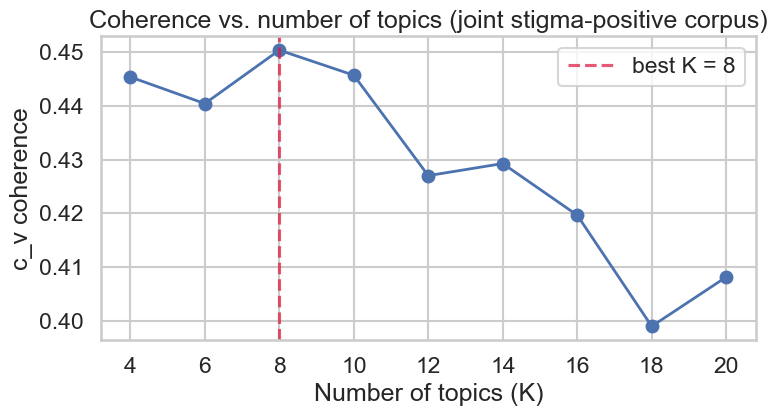

In [5]:
coherence_records = []
for k in tqdm(COHERENCE_K_RANGE, desc="Coherence sweep"):
    lda_k = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        passes=COHERENCE_PASSES,
        iterations=COHERENCE_ITERATIONS,
        chunksize=CHUNKSIZE,
        random_state=RANDOM_STATE,
        alpha="auto",
        eta="auto",
        eval_every=None,
    )
    score = CoherenceModel(
        model=lda_k, texts=processed_docs, dictionary=dictionary, coherence="c_v"
    ).get_coherence()
    coherence_records.append({"k": k, "coherence_c_v": score})
    print(f"  k={k:3d}  c_v={score:.4f}")

coherence_df = pd.DataFrame(coherence_records)
coherence_df.to_csv(OUT_DIR / "coherence_vs_k.csv", index=False)

BEST_K = int(coherence_df.loc[coherence_df["coherence_c_v"].idxmax(), "k"])
print(f"\nBest K by c_v coherence: {BEST_K}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(coherence_df["k"], coherence_df["coherence_c_v"], marker="o", linewidth=2)
ax.axvline(BEST_K, color="crimson", linestyle="--", alpha=0.7, label=f"best K = {BEST_K}")
ax.set_xlabel("Number of topics (K)")
ax.set_ylabel("c_v coherence")
ax.set_title("Coherence vs. number of topics (joint stigma-positive corpus)")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "coherence_vs_k.png", dpi=150)
plt.show()

NUM_TOPICS = BEST_K

## 5. Train the joint LDA

In [6]:
print(f"Training joint LDA: K={NUM_TOPICS}, passes={PASSES}, iterations={ITERATIONS} ...")
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    passes=PASSES,
    iterations=ITERATIONS,
    chunksize=CHUNKSIZE,
    random_state=RANDOM_STATE,
    alpha="auto",
    eta="auto",
    eval_every=None,
)

log_perplexity = float(lda_model.log_perplexity(corpus))
perplexity = float(np.exp2(-log_perplexity))

final_coherence_c_v = CoherenceModel(
    model=lda_model, texts=processed_docs, dictionary=dictionary, coherence="c_v"
).get_coherence()
final_coherence_umass = CoherenceModel(
    model=lda_model, corpus=corpus, dictionary=dictionary, coherence="u_mass"
).get_coherence()

print(f"log_perplexity    : {log_perplexity:.4f}")
print(f"perplexity        : {perplexity:.2f}")
print(f"coherence (c_v)   : {final_coherence_c_v:.4f}")
print(f"coherence (u_mass): {final_coherence_umass:.4f}")

lda_model.save(str(OUT_DIR / "lda_model.gensim"))
dictionary.save(str(OUT_DIR / "dictionary.gensim"))
print(f"\nSaved model + dictionary to {OUT_DIR.resolve()}")

Training joint LDA: K=8, passes=10, iterations=200 ...
log_perplexity    : -7.7836
perplexity        : 220.34
coherence (c_v)   : 0.4565
coherence (u_mass): -3.1893

Saved model + dictionary to /Users/derronli/Developer/IBEHS-4H03/reddit/topicmodel_joint_stigma


## 6. Standard LDA 

,topic,top_words
0,0,"cocaine, doctor, heroin, taking, effect, opiat..."
1,1,"weed, shit, meth, fuck, high, smoke, fucking, ..."
2,2,"money, company, legal, canada, cost, price, pa..."
3,3,"country, law, war, drug, government, cartel, a..."
4,4,"vaccine, corrupt, obama, hiv, national, drug, ..."
5,5,"guy, house, sex, woman, economy, car, girl, pa..."
6,6,"drug, use, problem, need, many, issue, mean, m..."
7,7,"time, life, year, feel, day, help, never, need..."


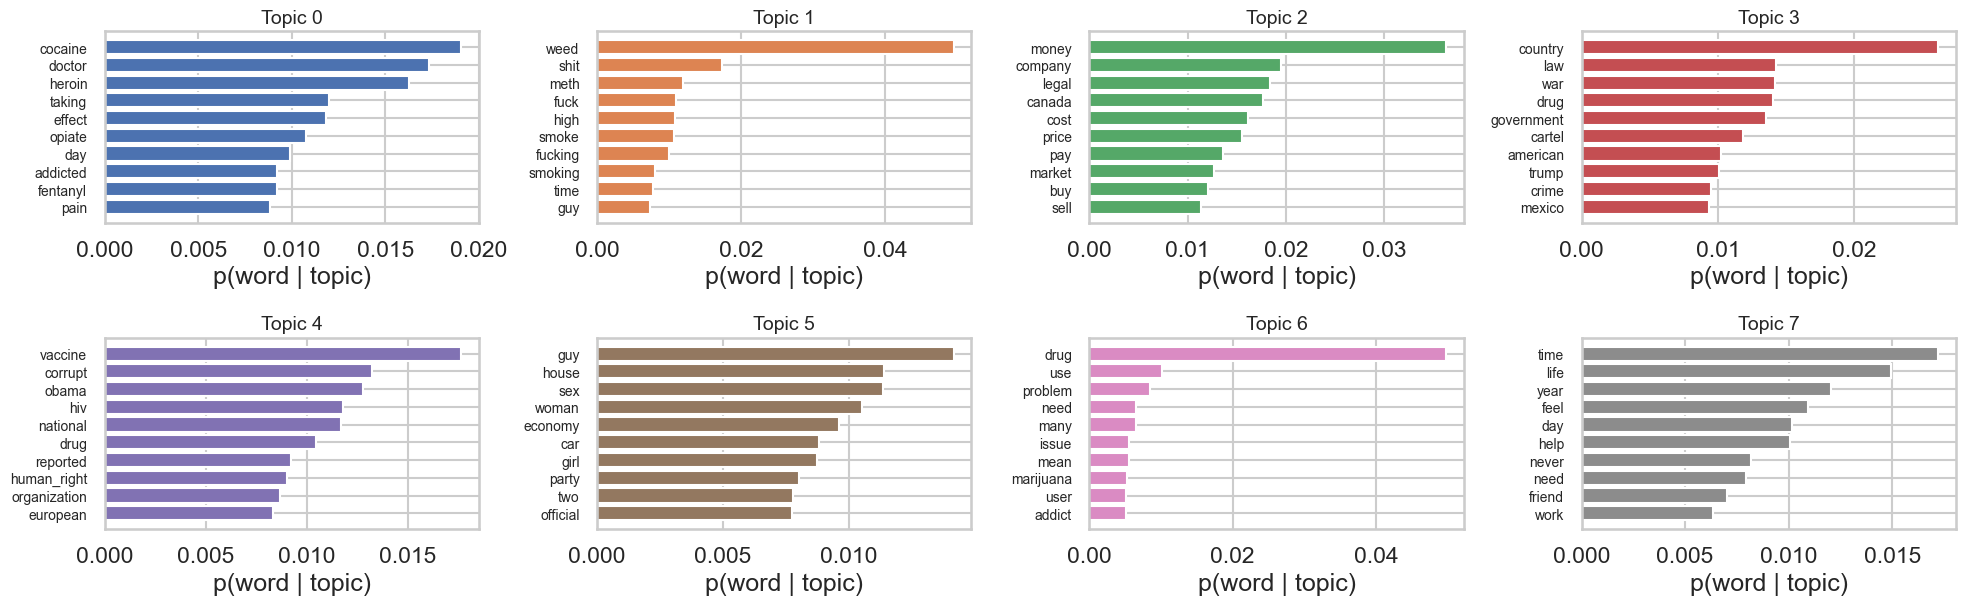

In [17]:
TOP_N = 10

def top_words_for_topic(t, n=TOP_N):
    return lda_model.show_topic(t, topn=n)

top_words_rows = []
for t in range(NUM_TOPICS):
    top = top_words_for_topic(t)
    top_words_rows.append({
        "topic": t,
        "top_words": ", ".join(w for w, _ in top),
        **{f"w{i+1}": w for i, (w, _) in enumerate(top)},
        **{f"p{i+1}": round(float(p), 4) for i, (_, p) in enumerate(top)},
    })
top_words_df = pd.DataFrame(top_words_rows)
top_words_df.to_csv(OUT_DIR / "top_words.csv", index=False)
display(top_words_df[["topic", "top_words"]])

n_cols = min(4, NUM_TOPICS)
n_rows = int(np.ceil(NUM_TOPICS / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.2 * n_rows))
axes = np.array(axes).reshape(-1)
for t in range(NUM_TOPICS):
    ax = axes[t]
    top = top_words_for_topic(t)
    words = [w for w, _ in top][::-1]
    probs = [p for _, p in top][::-1]
    ax.barh(words, probs, color=sns.color_palette("deep", NUM_TOPICS)[t % 10])
    ax.set_title(f"Topic {t}", fontsize=14)
    ax.set_xlabel("p(word | topic)")
    ax.tick_params(axis="y", labelsize=10)
for j in range(NUM_TOPICS, len(axes)):
    axes[j].axis("off")
fig.tight_layout()
fig.savefig(OUT_DIR / "topic_bars.png", dpi=150, bbox_inches="tight")
plt.show()

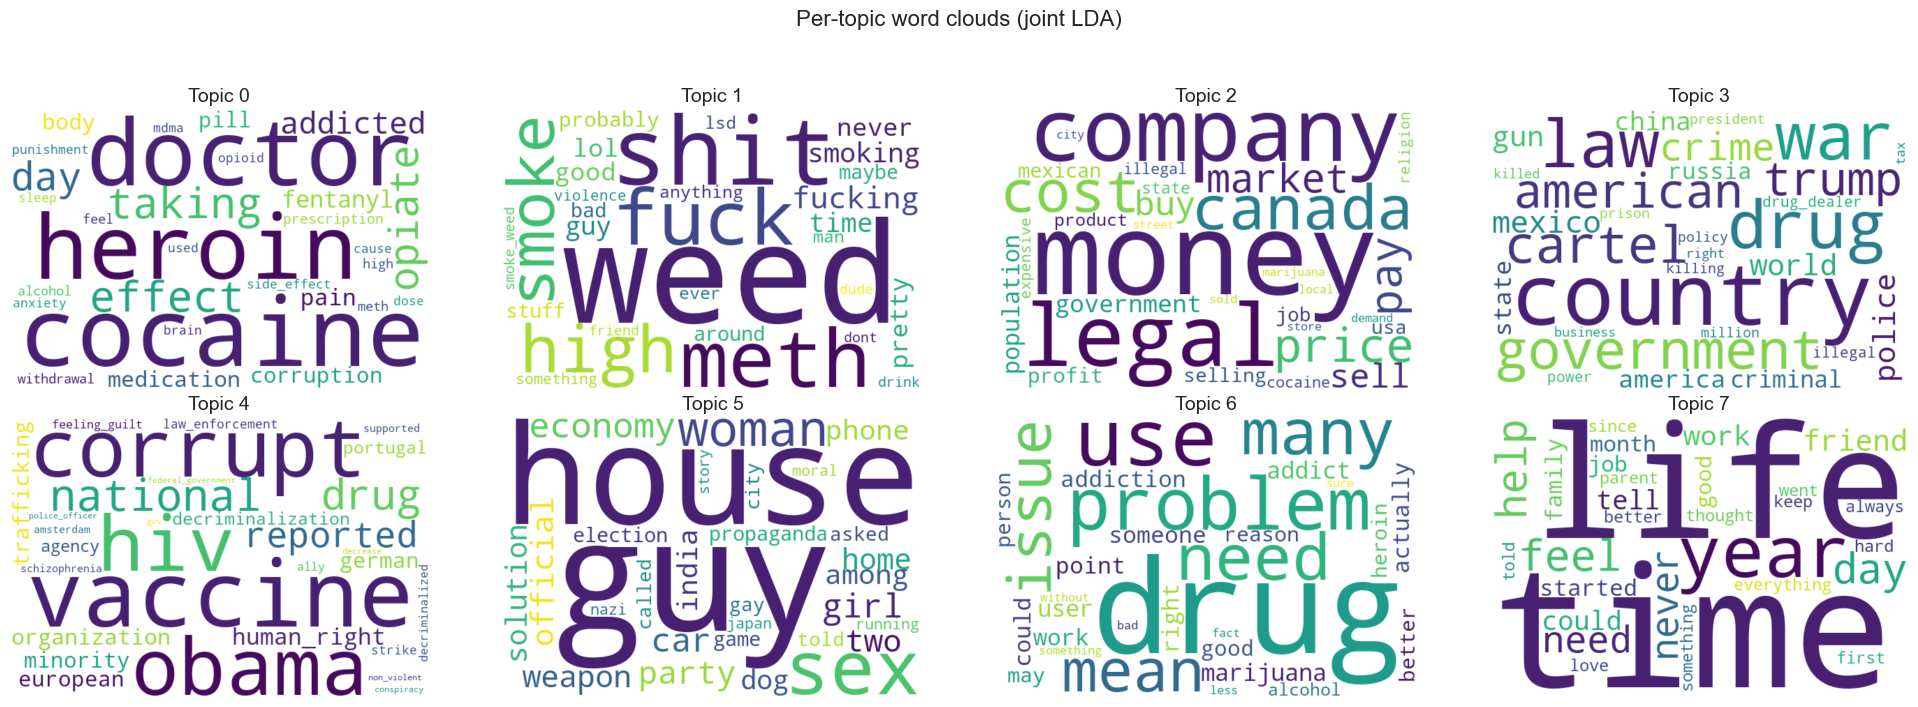

In [8]:
from wordcloud import WordCloud

WC_TOP_N = 30
n_cols = min(4, NUM_TOPICS)
n_rows = int(np.ceil(NUM_TOPICS / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = np.array(axes).reshape(-1)
for t in range(NUM_TOPICS):
    freqs = dict(lda_model.show_topic(t, topn=WC_TOP_N))
    wc = WordCloud(
        width=600, height=400, background_color="white",
        prefer_horizontal=0.95, random_state=RANDOM_STATE, colormap="viridis",
    ).generate_from_frequencies(freqs)
    axes[t].imshow(wc, interpolation="bilinear")
    axes[t].set_title(f"Topic {t}", fontsize=14)
    axes[t].axis("off")
for j in range(NUM_TOPICS, len(axes)):
    axes[j].axis("off")
fig.suptitle("Per-topic word clouds (joint LDA)", fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "topic_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Cohort-averaged topic distributions

For every document we infer the posterior topic distribution and then
average within each cohort. Two views:

- **Soft prevalence** $\bar{\theta}_{k}^{(c)} = \frac{1}{N_c} \sum_{d \in c} P(\text{topic}=k \mid d)$
  — the expected share of each topic in each cohort.
- **Hard (dominant) prevalence** — fraction of documents whose argmax
  topic is $k$. Coarser but easier for downstream proportion tests.

Inferring doc-topic distributions: 100%|██████████| 29717/29717 [00:01<00:00, 23634.01it/s]

Soft prevalence (mean posterior P(topic|doc) within cohort):


,T0,T1,T2,T3,T4,T5,T6,T7
drug,0.110,0.20,0.033,0.053,0.023,0.038,0.298,0.245
non_drug,0.057,0.14,0.070,0.145,0.021,0.046,0.356,0.165



Hard prevalence (fraction of docs with dominant topic = k):


,T0,T1,T2,T3,T4,T5,T6,T7
cohort,,,,,,,,
drug,0.072,0.199,0.002,0.003,0.016,0.003,0.425,0.280
non_drug,0.011,0.081,0.015,0.114,0.005,0.002,0.650,0.123


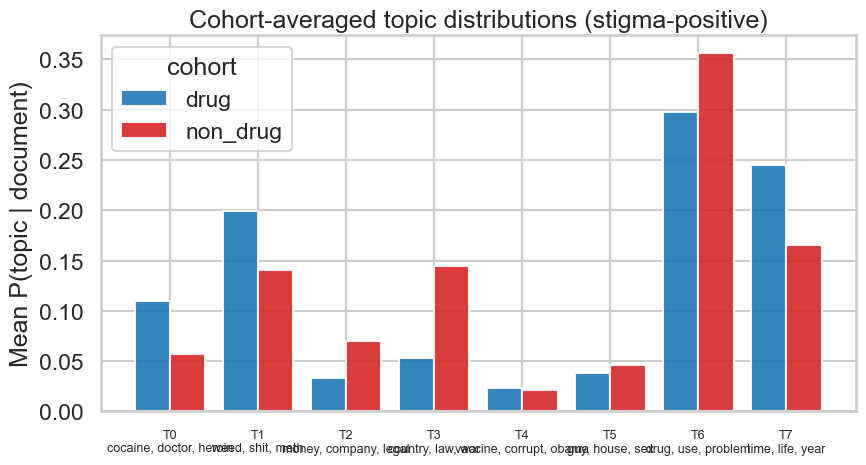

In [9]:
doc_topic_matrix = np.zeros((len(corpus), NUM_TOPICS), dtype=np.float32)
for i, bow in enumerate(tqdm(corpus, desc="Inferring doc-topic distributions")):
    for t, p in lda_model.get_document_topics(bow, minimum_probability=0.0):
        doc_topic_matrix[i, t] = p

dominant_topic = doc_topic_matrix.argmax(axis=1)
dominant_prob = doc_topic_matrix.max(axis=1)

cohort_idx = {c: np.where(cohort == c)[0] for c in COHORT_ORDER}

# Soft prevalence (mean posterior topic probability within a cohort)
soft_prevalence = np.stack(
    [doc_topic_matrix[cohort_idx[c]].mean(axis=0) for c in COHORT_ORDER], axis=0
)
soft_prevalence_df = pd.DataFrame(
    soft_prevalence, index=COHORT_ORDER,
    columns=[f"T{t}" for t in range(NUM_TOPICS)],
)
soft_prevalence_df.to_csv(OUT_DIR / "cohort_soft_prevalence.csv")

# Hard (dominant-topic) prevalence
hard_counts = pd.crosstab(pd.Series(cohort, name="cohort"),
                          pd.Series(dominant_topic, name="topic"))
hard_counts = hard_counts.reindex(index=COHORT_ORDER,
                                  columns=list(range(NUM_TOPICS)), fill_value=0)
hard_prevalence_df = hard_counts.div(hard_counts.sum(axis=1), axis=0)
hard_prevalence_df.columns = [f"T{t}" for t in hard_prevalence_df.columns]
hard_prevalence_df.to_csv(OUT_DIR / "cohort_hard_prevalence.csv")

print("Soft prevalence (mean posterior P(topic|doc) within cohort):")
display(soft_prevalence_df.round(3))
print("\nHard prevalence (fraction of docs with dominant topic = k):")
display(hard_prevalence_df.round(3))

# Side-by-side grouped bar chart of soft prevalence
fig, ax = plt.subplots(figsize=(max(9, 0.9 * NUM_TOPICS), 5))
x = np.arange(NUM_TOPICS)
width = 0.4
for i, c in enumerate(COHORT_ORDER):
    ax.bar(x + (i - 0.5) * width, soft_prevalence[i], width=width,
           label=c, color=COHORT_COLORS[c], alpha=0.9)
tick_labels = [
    f"T{t}\n{', '.join(w for w, _ in lda_model.show_topic(t, topn=3))}"
    for t in range(NUM_TOPICS)
]
ax.set_xticks(x)
ax.set_xticklabels(tick_labels, fontsize=9)
ax.set_ylabel("Mean P(topic | document)")
ax.set_title("Cohort-averaged topic distributions (stigma-positive)")
ax.legend(title="cohort")
fig.tight_layout()
fig.savefig(OUT_DIR / "cohort_topic_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Differential topic prevalence

$\Delta_k = P(\text{topic}=k \mid \text{drug}) - P(\text{topic}=k \mid \text{non\_drug})$

Positive bars = topics over-represented in insider (drug-subreddit)
stigmatizing discourse. Negative bars = over-represented in outsider
(non-drug) stigmatizing discourse. 95% confidence intervals come from a
non-parametric bootstrap over documents within each cohort.

Bootstrapping prevalence CIs: 100%|██████████| 500/500 [00:00<00:00, 2279.64it/s]


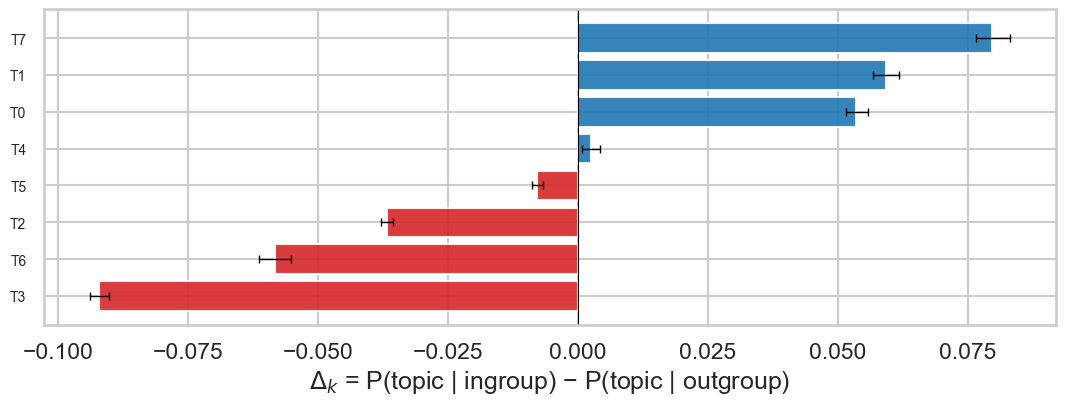

,topic,p_drug,p_non_drug,delta_drug_minus_non,ci_lower,ci_upper,top_words
0,3,0.0527,0.1449,-0.0922,-0.0940,-0.0904,"country, law, war, drug, government, cartel, a..."
1,6,0.2979,0.3562,-0.0583,-0.0614,-0.0553,"drug, use, problem, need, many, issue, mean, m..."
2,2,0.0330,0.0697,-0.0367,-0.0380,-0.0355,"money, company, legal, canada, cost, price, pa..."
3,5,0.0381,0.0460,-0.0078,-0.0088,-0.0068,"guy, house, sex, woman, economy, car, girl, pa..."
4,4,0.0233,0.0208,0.0025,0.0008,0.0042,"vaccine, corrupt, obama, hiv, national, drug, ..."
5,0,0.1102,0.0566,0.0535,0.0515,0.0557,"cocaine, doctor, heroin, taking, effect, opiat..."
6,1,0.1997,0.1405,0.0593,0.0567,0.0618,"weed, shit, meth, fuck, high, smoke, fucking, ..."
7,7,0.2451,0.1654,0.0797,0.0767,0.0831,"time, life, year, feel, day, help, never, need..."


In [18]:
rng = np.random.default_rng(RANDOM_STATE)

idx_drug = cohort_idx["drug"]
idx_non = cohort_idx["non_drug"]
probs_drug = doc_topic_matrix[idx_drug]
probs_non = doc_topic_matrix[idx_non]

delta_point = probs_drug.mean(axis=0) - probs_non.mean(axis=0)

boot_deltas = np.empty((N_BOOTSTRAP, NUM_TOPICS), dtype=np.float32)
for b in tqdm(range(N_BOOTSTRAP), desc="Bootstrapping prevalence CIs"):
    s_d = rng.integers(0, len(idx_drug), size=len(idx_drug))
    s_n = rng.integers(0, len(idx_non), size=len(idx_non))
    boot_deltas[b] = probs_drug[s_d].mean(axis=0) - probs_non[s_n].mean(axis=0)

ci_lower = np.quantile(boot_deltas, ALPHA / 2, axis=0)
ci_upper = np.quantile(boot_deltas, 1 - ALPHA / 2, axis=0)

diff_df = pd.DataFrame({
    "topic": np.arange(NUM_TOPICS),
    "p_drug": probs_drug.mean(axis=0),
    "p_non_drug": probs_non.mean(axis=0),
    "delta_drug_minus_non": delta_point,
    "ci_lower": ci_lower,
    "ci_upper": ci_upper,
    "top_words": [", ".join(w for w, _ in lda_model.show_topic(t, topn=TOP_N))
                  for t in range(NUM_TOPICS)],
}).sort_values("delta_drug_minus_non").reset_index(drop=True)
diff_df.to_csv(OUT_DIR / "differential_prevalence.csv", index=False)

fig, ax = plt.subplots(figsize=(11, max(4, 0.55 * NUM_TOPICS)))
order = diff_df["topic"].to_list()
y = np.arange(len(order))
colors = ["#1f77b4" if d > 0 else "#d62728" for d in diff_df["delta_drug_minus_non"]]
ax.barh(y, diff_df["delta_drug_minus_non"], color=colors, alpha=0.9,
        xerr=[diff_df["delta_drug_minus_non"] - diff_df["ci_lower"],
              diff_df["ci_upper"] - diff_df["delta_drug_minus_non"]],
        error_kw=dict(ecolor="black", lw=1, capsize=3))
labels = [f"T{int(t)}"
          for t in order]
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(r"$\Delta_k$ = P(topic | ingroup) − P(topic | outgroup)")
fig.tight_layout()
fig.savefig(OUT_DIR / "differential_prevalence.png", dpi=150, bbox_inches="tight")
plt.show()

display(diff_df.round(4))

## 9. Per-topic significance and effect size

Two complementary tests per topic, both corrected with
**Benjamini-Hochberg FDR** across the K topics:

- **Two-proportion z-test** on dominant-topic counts
  ($\hat{p}_{k}^{\text{drug}} = \#\{d : \arg\max_k \theta_d = k\} / N_{\text{drug}}$).
  Uses a pooled variance, approximately $\chi^2$-equivalent, easy to
  report.
- **Welch's t-test** on the per-document posterior probabilities
  $\theta_{d,k}$ between cohorts (unequal variance). More information
  per doc than the hard argmax.

Effect size reported alongside is **Cohen's *h*** for the two
proportions,
$h = 2(\arcsin \sqrt{p_1} - \arcsin \sqrt{p_2})$;
conventional thresholds: 0.2 small, 0.5 medium, 0.8 large.

In [11]:
def two_proportion_z(x1, n1, x2, n2):
    """Pooled two-proportion z-test. Returns (z, two-sided p)."""
    p1, p2 = x1 / n1, x2 / n2
    p_pool = (x1 + x2) / (n1 + n2)
    se = math.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    if se == 0:
        return 0.0, 1.0
    z = (p1 - p2) / se
    p = 2 * (1 - norm.cdf(abs(z)))
    return z, p


def cohens_h(p1, p2):
    return 2 * (math.asin(math.sqrt(p1)) - math.asin(math.sqrt(p2)))


n_drug = len(idx_drug)
n_non = len(idx_non)

rows = []
for t in range(NUM_TOPICS):
    x_drug = int((dominant_topic[idx_drug] == t).sum())
    x_non = int((dominant_topic[idx_non] == t).sum())
    p_drug = x_drug / n_drug
    p_non = x_non / n_non

    z, p_prop = two_proportion_z(x_drug, n_drug, x_non, n_non)
    tstat, p_welch = ttest_ind(probs_drug[:, t], probs_non[:, t], equal_var=False)
    h = cohens_h(p_drug, p_non)

    rows.append({
        "topic": t,
        "top_words": ", ".join(w for w, _ in lda_model.show_topic(t, topn=TOP_N)),
        "n_drug": n_drug, "n_non_drug": n_non,
        "dom_drug": x_drug, "dom_non_drug": x_non,
        "p_drug_hard": p_drug, "p_non_drug_hard": p_non,
        "delta_hard": p_drug - p_non,
        "z_prop": z, "p_prop": p_prop,
        "p_drug_soft": float(probs_drug[:, t].mean()),
        "p_non_drug_soft": float(probs_non[:, t].mean()),
        "delta_soft": float(probs_drug[:, t].mean() - probs_non[:, t].mean()),
        "t_welch": float(tstat), "p_welch": float(p_welch),
        "cohens_h": h,
    })

stats_df = pd.DataFrame(rows)
stats_df["q_prop_bh"] = multipletests(stats_df["p_prop"], method="fdr_bh")[1]
stats_df["q_welch_bh"] = multipletests(stats_df["p_welch"], method="fdr_bh")[1]
stats_df["sig_prop"] = stats_df["q_prop_bh"] < ALPHA
stats_df["sig_welch"] = stats_df["q_welch_bh"] < ALPHA

stats_df = stats_df.sort_values("delta_soft").reset_index(drop=True)
stats_df.to_csv(OUT_DIR / "differential_stats.csv", index=False)

display(
    stats_df[[
        "topic", "top_words",
        "p_drug_hard", "p_non_drug_hard", "delta_hard",
        "z_prop", "q_prop_bh",
        "delta_soft", "t_welch", "q_welch_bh",
        "cohens_h", "sig_prop", "sig_welch",
    ]].round(4)
)

n_sig = int(stats_df["sig_prop"].sum())
print(
    f"\n{n_sig}/{NUM_TOPICS} topics differ between cohorts at BH-FDR q<{ALPHA} "
    f"(two-proportion z-test on dominant-topic counts)."
)

,topic,top_words,p_drug_hard,p_non_drug_hard,delta_hard,z_prop,q_prop_bh,delta_soft,t_welch,q_welch_bh,cohens_h,sig_prop,sig_welch
0,3,"country, law, war, drug, government, cartel, a...",0.0033,0.1138,-0.1105,-37.8706,0.0000,-0.0922,-97.3965,0.000,-0.5733,True,True
1,6,"drug, use, problem, need, many, issue, mean, m...",0.4249,0.6498,-0.2249,-38.5997,0.0000,-0.0583,-38.6857,0.000,-0.4551,True,True
2,2,"money, company, legal, canada, cost, price, pa...",0.0018,0.0150,-0.0132,-11.7204,0.0000,-0.0367,-60.0311,0.000,-0.1608,True,True
3,5,"guy, house, sex, woman, economy, car, girl, pa...",0.0030,0.0018,0.0012,2.0451,0.0408,-0.0078,-15.4591,0.000,0.0237,True,True
4,4,"vaccine, corrupt, obama, hiv, national, drug, ...",0.0155,0.0050,0.0106,9.3109,0.0000,0.0025,2.8785,0.004,0.1091,True,True
5,0,"cocaine, doctor, heroin, taking, effect, opiat...",0.0724,0.0108,0.0616,27.7318,0.0000,0.0535,50.0149,0.000,0.3362,True,True
6,1,"weed, shit, meth, fuck, high, smoke, fucking, ...",0.1992,0.0812,0.1180,29.7630,0.0000,0.0593,44.4105,0.000,0.3474,True,True
7,7,"time, life, year, feel, day, help, never, need...",0.2799,0.1225,0.1573,34.2176,0.0000,0.0797,48.5455,0.000,0.3997,True,True



8/8 topics differ between cohorts at BH-FDR q<0.05 (two-proportion z-test on dominant-topic counts).


## 10. Overall divergence: Jensen-Shannon between cohort distributions

One scalar for "how thematically different are insider and outsider
stigmatizing discourse?" Jensen-Shannon is a symmetric, bounded-in-
$[0, 1]$ (base-2 log) distance between the two cohort-averaged topic
distributions; we report $\text{JSD}^2$ in nats (scipy convention) along
with a bootstrap 95% CI.

For context, we also bootstrap a **null** distribution where cohort
labels are shuffled — the observed JSD should sit well above the null
band if the two cohorts genuinely differ.

Observed JSD(drug || non_drug) = 0.1971  (distance, base-2)
Bootstrap 95% CI      = [0.1942, 0.2001]
Permutation null 95% band = [0.0020, 0.0075]
Permutation p-value       = 0  (fraction of shuffles with JSD >= observed)


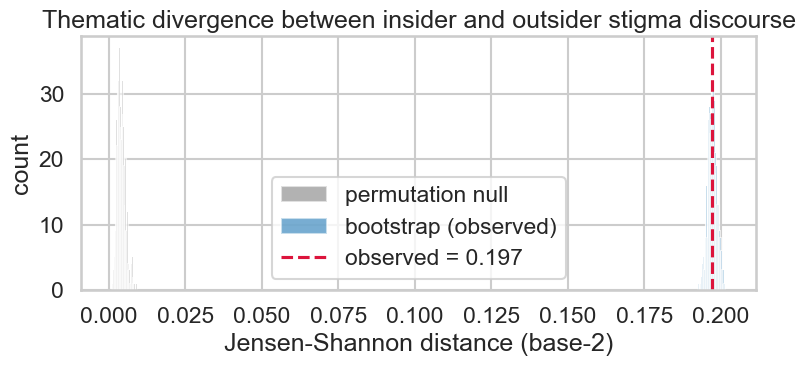

In [12]:
def jsd_distance(p, q, base=2):
    p = np.asarray(p, dtype=np.float64); p /= p.sum()
    q = np.asarray(q, dtype=np.float64); q /= q.sum()
    return float(jensenshannon(p, q, base=base))

observed_jsd = jsd_distance(probs_drug.mean(axis=0), probs_non.mean(axis=0))
print(f"Observed JSD(drug || non_drug) = {observed_jsd:.4f}  (distance, base-2)")

boot_jsd = np.empty(N_BOOTSTRAP, dtype=np.float32)
for b in range(N_BOOTSTRAP):
    s_d = rng.integers(0, len(idx_drug), size=len(idx_drug))
    s_n = rng.integers(0, len(idx_non), size=len(idx_non))
    boot_jsd[b] = jsd_distance(probs_drug[s_d].mean(axis=0),
                               probs_non[s_n].mean(axis=0))
ci_lo, ci_hi = np.quantile(boot_jsd, [ALPHA / 2, 1 - ALPHA / 2])
print(f"Bootstrap 95% CI      = [{ci_lo:.4f}, {ci_hi:.4f}]")

# Permutation null: shuffle cohort labels
all_probs = doc_topic_matrix
null_jsd = np.empty(N_BOOTSTRAP, dtype=np.float32)
perm_rng = np.random.default_rng(RANDOM_STATE + 1)
N = len(all_probs)
for b in range(N_BOOTSTRAP):
    perm = perm_rng.permutation(N)
    a = all_probs[perm[:n_drug]].mean(axis=0)
    c = all_probs[perm[n_drug:n_drug + n_non]].mean(axis=0)
    null_jsd[b] = jsd_distance(a, c)
null_lo, null_hi = np.quantile(null_jsd, [ALPHA / 2, 1 - ALPHA / 2])
perm_p = float((null_jsd >= observed_jsd).mean())
print(f"Permutation null 95% band = [{null_lo:.4f}, {null_hi:.4f}]")
print(f"Permutation p-value       = {perm_p:.4g}  "
      f"(fraction of shuffles with JSD >= observed)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(null_jsd, bins=40, alpha=0.6, label="permutation null", color="gray")
ax.hist(boot_jsd, bins=40, alpha=0.6, label="bootstrap (observed)", color="#1f77b4")
ax.axvline(observed_jsd, color="crimson", linestyle="--",
           label=f"observed = {observed_jsd:.3f}")
ax.set_xlabel("Jensen-Shannon distance (base-2)")
ax.set_ylabel("count")
ax.set_title("Thematic divergence between insider and outsider stigma discourse")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "jsd_bootstrap.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame({
    "observed_jsd": [observed_jsd],
    "boot_ci_lower": [float(ci_lo)],
    "boot_ci_upper": [float(ci_hi)],
    "perm_null_lower": [float(null_lo)],
    "perm_null_upper": [float(null_hi)],
    "perm_p_value": [perm_p],
}).to_csv(OUT_DIR / "jsd_summary.csv", index=False)

## 11. Representative documents per topic, stratified by cohort

For each topic, pull the top 2 documents with the highest posterior
probability from **each** cohort. This lets you see, qualitatively,
whether insiders and outsiders use the same topic in substantively
different ways (which is the most interesting outcome — a topic that is
prevalent in both cohorts but is realized through different language
and framing).

In [13]:
REP_DOCS_PER_COHORT = 2
REP_SNIPPET_CHARS = 400

rep_rows = []
for t in range(NUM_TOPICS):
    top_words = ", ".join(w for w, _ in lda_model.show_topic(t, topn=TOP_N))
    print(f"\n=== Topic {t} === [{top_words}]")
    for c in COHORT_ORDER:
        idx_c = cohort_idx[c]
        scores_c = doc_topic_matrix[idx_c, t]
        top_local = np.argsort(scores_c)[::-1][:REP_DOCS_PER_COHORT]
        print(f"--- cohort = {c} ---")
        for rank, li in enumerate(top_local, 1):
            gi = int(idx_c[li])
            prob = float(doc_topic_matrix[gi, t])
            text = documents[gi].replace("\n", " ").strip()
            snippet = text[:REP_SNIPPET_CHARS] + ("..." if len(text) > REP_SNIPPET_CHARS else "")
            cid = df_all.iloc[gi].get("comment_id", "")
            print(f"  [{rank}] p={prob:.3f}  comment_id={cid}")
            print(f"      {snippet}")
            rep_rows.append({
                "topic": t, "cohort": c, "rank": rank,
                "prob": prob, "comment_id": cid, "text": text,
            })

pd.DataFrame(rep_rows).to_csv(OUT_DIR / "representative_docs_by_cohort.csv", index=False)


=== Topic 0 === [cocaine, doctor, heroin, taking, effect, opiate, day, addicted, fentanyl, pain]
--- cohort = drug ---
  [1] p=0.723  comment_id=e14tve8
      Pro tip: NMDA antagonists drastically reduce and often times reverse the development of tolerance to amphetamine type stimulants.   Pick up some dextromethorphan containing gel capsules from a CVS, and take it in doses of no more than 80mg at a time, and you will notice a difference. Or, purchase a memantine solution online and dose 20mg a day. Both help prevent tolerance fairly strongly.  Will 5m...
  [2] p=0.695  comment_id=enst2d1
      The oxy would completely overpower the Kratom. In my experience it’s a waste of Kratom.  No amount of Kratom is going to feel as potent as oxycodone.  Oxy and kratom  So just a general question, I heard kratom has a better binding affinity than oxy and was curious if I’d feel the oxycodone tonight after taking my morning dose of ~4 grams of kratom at 7 am.  Also as a side note, how much oxy wo

## 12. Interactive pyLDAvis

In [14]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, dictionary, sort_topics=False)
pyLDAvis.save_html(vis, str(OUT_DIR / "ldavis.html"))
print(f"Saved interactive visualization to {OUT_DIR / 'ldavis.html'}")
vis

Saved interactive visualization to ../reddit/topicmodel_joint_stigma/ldavis.html


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.097498 -0.154608       1        1   7.565481
1     -0.177358 -0.087153       2        1  14.133234
2      0.143076  0.293622       3        1   4.873302
3      0.043617  0.214948       4        1   9.529132
4      0.397664 -0.234215       5        1   2.777703
5     -0.055715  0.070020       6        1   4.629110
6     -0.094549 -0.018816       7        1  31.396101
7     -0.159238 -0.083798       8        1  25.095936, topic_info=           Term          Freq         Total Category  logprob  loglift
13         drug  27536.000000  27536.000000  Default  30.0000  30.0000
343        weed  11114.000000  11114.000000  Default  29.0000  29.0000
1623    country   4015.000000   4015.000000  Default  28.0000  28.0000
33        money   3036.000000   3036.000000  Default  27.0000  27.0000
260        shit   4016.000000   4016.000000  Default  26.0000  26.0000
...         ...           ...           ...      ...      ...      ...
61       always   1759.561838   3172.127262   Topic8  -5.4209   0.7931
20         good   2008.197616   5495.075826   Topic8  -5.2888   0.3758
375      better   1759.103351   3855.321030   Topic8  -5.4212   0.5978
261       since   1628.540225   3010.902289   Topic8  -5.4983   0.7679
268   something   1695.352578   4635.329890   Topic8  -5.4581   0.3766

[493 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
6329      3  0.995768  abortion
4230      6  0.993171   accused
4230      7  0.004263   accused
312       2  0.997104      acid
54        1  0.006548  actually
...     ...       ...       ...
533       3  0.011050      year
533       4  0.077956      year
533       6  0.000757      year
533       7  0.138354      year
533       8  0.726131      year

[1005 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7, 8])

## 13. Reported metrics and artefacts

In [15]:
summary_metrics = {
    "csv_path_drug": CSV_PATHS["drug"],
    "csv_path_non_drug": CSV_PATHS["non_drug"],
    "text_column": TEXT_COL,
    "label_column": LABEL_COL,
    "stigma_value": STIGMA_VALUE,
    "n_documents_drug": int(n_drug),
    "n_documents_non_drug": int(n_non),
    "n_documents_total": int(n_drug + n_non),
    "vocab_size": len(dictionary),
    "num_topics_K": NUM_TOPICS,
    "coherence_c_v": round(float(final_coherence_c_v), 4),
    "coherence_u_mass": round(float(final_coherence_umass), 4),
    "log_perplexity": round(float(log_perplexity), 4),
    "perplexity": round(float(perplexity), 2),
    "jsd_observed": round(float(observed_jsd), 4),
    "jsd_ci_lower": round(float(ci_lo), 4),
    "jsd_ci_upper": round(float(ci_hi), 4),
    "jsd_perm_p": round(float(perm_p), 4),
    "n_topics_sig_prop_bh": int(stats_df["sig_prop"].sum()),
    "n_topics_sig_welch_bh": int(stats_df["sig_welch"].sum()),
    "passes": PASSES, "iterations": ITERATIONS,
    "no_below": NO_BELOW, "no_above": NO_ABOVE,
    "random_state": RANDOM_STATE, "lemmatize": LEMMATIZE,
    "n_bootstrap": N_BOOTSTRAP, "alpha": ALPHA,
}
summary_df = pd.DataFrame([summary_metrics]).T.rename(columns={0: "value"})
summary_df.to_csv(OUT_DIR / "run_summary.csv")

print("Run summary:")
for k, v in summary_metrics.items():
    print(f"  {k:26s} {v}")

print("\nArtifacts written to", OUT_DIR.resolve())
for p in sorted(OUT_DIR.iterdir()):
    print(" -", p.name)

Run summary:
  csv_path_drug              ../reddit/drug_subreddit_pred_merge.csv
  csv_path_non_drug          ../reddit/non_drug_subreddit_pred_merge.csv
  text_column                dla_text
  label_column               final_label
  stigma_value               1
  n_documents_drug           12749
  n_documents_non_drug       16968
  n_documents_total          29717
  vocab_size                 7918
  num_topics_K               8
  coherence_c_v              0.4565
  coherence_u_mass           -3.1893
  log_perplexity             -7.7836
  perplexity                 220.34
  jsd_observed               0.1971
  jsd_ci_lower               0.1942
  jsd_ci_upper               0.2001
  jsd_perm_p                 0.0
  n_topics_sig_prop_bh       8
  n_topics_sig_welch_bh      8
  passes                     10
  iterations                 200
  no_below                   20
  no_above                   0.5
  random_state               42
  lemmatize                  True
  n_bootstrap       